- Nicolas Banatt

In [113]:
!python --version

Python 3.13.7


In [114]:
%pip install numpy
%pip install pandas
%pip install scikit-learn
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [115]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [116]:
df = pd.read_csv('MergedData_model.csv')

df.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_label,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,1,0.50
1,10,579.0,229.0,40.0,0.0,0.0,1,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0,0.75


In [117]:
# Split target variable and attributes
attr = df.drop(columns=['RRV_label', 'Assmnt'])
target = df['RRV_label']

# Split the data into training and testing sets
attr_train, attr_test, target_train, target_test = train_test_split(attr, target, test_size=0.3, random_state=6)

model = DecisionTreeClassifier()
model.fit(attr_train,target_train)
target_pred = model.predict(attr_test)

print(confusion_matrix(target_test,target_pred))
print(classification_report(target_test,target_pred))

[[18  8]
 [ 1 10]]
              precision    recall  f1-score   support

           0       0.95      0.69      0.80        26
           1       0.56      0.91      0.69        11

    accuracy                           0.76        37
   macro avg       0.75      0.80      0.74        37
weighted avg       0.83      0.76      0.77        37



In [118]:
plt.figure(figsize=(50,30), dpi=250)
plot_tree(model,fontsize=20,filled=True,feature_names=attr.columns, class_names=["No Increase", "Increase"])

[Text(0.5, 0.9285714285714286, 'Baseline_RRVscore <= 0.646\ngini = 0.477\nsamples = 84\nvalue = [51.0, 33.0]\nclass = No Increase'),
 Text(0.2222222222222222, 0.7857142857142857, 'Avg_Daily_Mod_Week_Min <= 12.0\ngini = 0.394\nsamples = 37\nvalue = [10, 27]\nclass = Increase'),
 Text(0.3611111111111111, 0.8571428571428572, 'True  '),
 Text(0.1111111111111111, 0.6428571428571429, 'Baseline_RRVscore <= 0.2\ngini = 0.397\nsamples = 11\nvalue = [8, 3]\nclass = No Increase'),
 Text(0.05555555555555555, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]\nclass = No Increase'),
 Text(0.16666666666666666, 0.5, 'Avg_Daily_Mod_Week_Min <= 5.0\ngini = 0.48\nsamples = 5\nvalue = [2, 3]\nclass = Increase'),
 Text(0.1111111111111111, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = No Increase'),
 Text(0.2222222222222222, 0.35714285714285715, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]\nclass = Increase'),
 Text(0.3333333333333333, 0.6428571428571429, 'Avg_Daily_Sed_Week_Min <= 1069.5\n

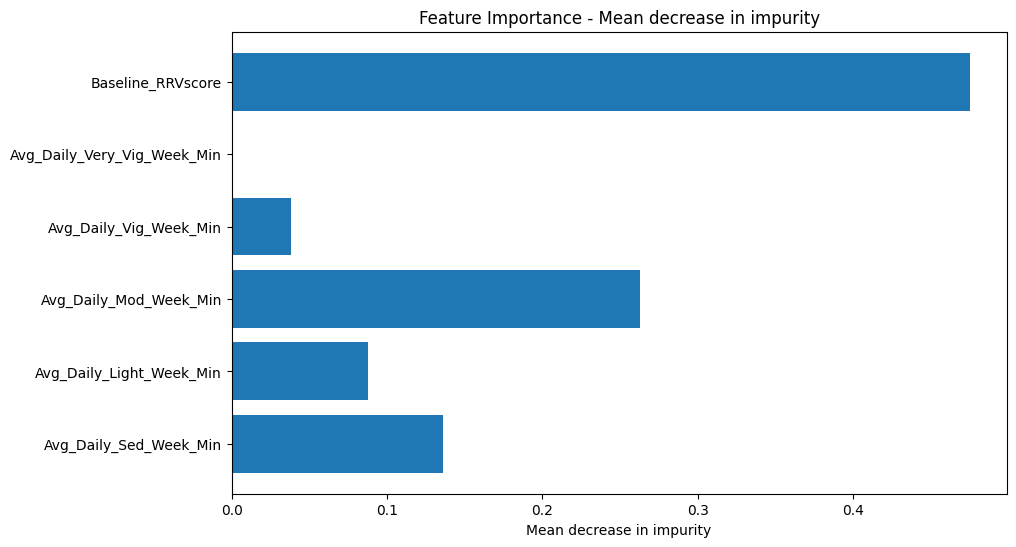

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.barh(range(len(model.feature_importances_)), model.feature_importances_, align='center')
plt.yticks(range(len(model.feature_importances_)), attr.columns)
plt.xlabel('Mean decrease in impurity')
plt.title('Feature Importance - Mean decrease in impurity')
plt.show()

In [121]:
df[['Avg_Daily_Very_Vig_Week_Min','RRV_label']].corr()

,Avg_Daily_Very_Vig_Week_Min,RRV_label
Avg_Daily_Very_Vig_Week_Min,1.000000,-0.127719
RRV_label,-0.127719,1.000000
